#Datathon Passos Mágicos: Impacto Educacional e Modelagem Preditiva

##Introdução e Contextualização do Negócio:

A Associação Passos Mágicos tem uma trajetória de mais de 30 anos trabalhando na transformação da vida de crianças e jovens de baixa renda no município de Embu-Guaçu, utilizando a educação de qualidade, auxílio psicológico e psicopedagógico como ferramentas de mudança
.

# 🎯 Objetivos deste Notebook (Fase de Analytics & Storytelling Gerencial)

O propósito central deste notebook é aplicar estratégias de *Data Analytics* sobre a base de dados da Pesquisa Extensiva do Desenvolvimento Educacional (PEDE) referente aos anos de 2022, 2023 e 2024.

Nesta etapa, nossa investigação focará em construir um **Storytelling Analítico e Gerencial**, respondendo estritamente às dores de negócio listadas pela associação:

### 🏢 Resolução das Perguntas de Negócio da ONG

* **1. Adequação do Nível (IAN):** Qual é o perfil geral de defasagem dos alunos ($IAN$) e como ele evolui ao longo dos anos, mapeando quantos alunos estão moderadamente ou severamente defasados?
* **2. Desempenho Acadêmico (IDA):** O desempenho acadêmico médio ($IDA$) está melhorando, estagnado ou caindo ao longo das fases e anos? *(Com ênfase especial na investigação do risco de reprovação escolar no colégio regular via variável `Aumento_Df_Ano_Seguinte`).*
* **3. Engajamento nas Atividades (IEG):** O grau de engajamento dos alunos ($IEG$) tem relação direta com seus indicadores de desempenho ($IDA$) e do ponto de virada ($IPV$)?
* **4. Autoavaliação (IAA):** As percepções dos alunos sobre si mesmos ($IAA$) são coerentes com seu desempenho real ($IDA$) e engajamento ($IEG$)?
* **5. Aspectos Psicossociais (IPS):** Há padrões psicossociais ($IPS$) que antecedem quedas de desempenho acadêmico ou de engajamento?
* **6. Aspectos Psicopedagógicos (IPP):** As avaliações psicopedagógicas ($IPP$) confirmam ou contradizem a defasagem identificada pelo $IAN$?
* **7. Ponto de Virada (IPV):** Quais comportamentos acadêmicos, emocionais ou de engajamento mais influenciam o $IPV$ ao longo do tempo?
* **8. Multidimensionalidade dos Indicadores:** Quais combinações de indicadores ($\text{IDA} + \text{IEG} + \text{IPS} + \text{IPP}$) elevam mais a nota global do aluno ($INDE$)?
* **10. Efetividade do Programa:** Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?
* **11. Insights e Criatividade:** Adicionar visões não abordadas nas perguntas, gerando novas métricas que tragam sugestões de melhoria no processo atual da Passos Mágicos.

---

> ⚠️ **Nota de Escopo do Projeto (Fase 2 - Modelo Preditivo & Deploy):**
>As perguntas relacionadas à **Previsão de Risco com Machine Learning (Pergunta 9)** — contemplando as etapas de *Feature Engineering*, separação de treino/teste, modelagem preditiva e avaliação de resultados —, bem como o desenvolvimento da aplicação **Streamlit via Community Cloud**, serão desenvolvidas e disponibilizadas em um **notebook e repositório dedicados**. Este arquivo atual concentra-se 100% na fundação analítica, tratamento e exploração dos dados (*EDA*).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carregando a base de dados
df = pd.read_csv('df_passos_magicos.csv')
display(df.head())

,Ano,RA,Ano de Nascimento,Gênero,Ano ingresso,Instituição de ensino,Fase,Fase Ideal,Defasagem,INDE,...,Mat,Por,Ing,IEG,IAA,IPS,IPP,IPV,Pedra,Aumento_Df_Ano_Seguinte
0,2022,1,2003,Feminino,2016,Escola Pública,7,8,-1,5.78,...,2.7,3.5,6.0,4.1,8.3,5.6,8.17,7.28,Quartzo,NaN
1,2022,2,2005,Feminino,2017,Escola Privada,7,7,0,7.06,...,6.3,4.5,9.7,5.2,8.8,6.3,7.89,6.78,Ametista,NaN
2,2022,3,2005,Feminino,2016,Escola Privada,7,7,0,6.59,...,5.8,4.0,6.9,7.9,0.0,5.6,8.20,7.56,Ágata,NaN
3,2022,4,2005,Masculino,2017,Escola Privada,7,7,0,5.95,...,2.8,3.5,8.7,4.5,8.8,5.6,5.55,5.28,Quartzo,NaN
4,2022,5,2005,Feminino,2016,Escola Privada,7,7,0,7.43,...,7.0,2.9,5.7,8.6,7.9,5.6,8.39,7.39,Ametista,NaN


In [ ]:
# Visualizando a estrutura para confirmar
print(f"Base carregada com {df.shape[0]} linhas e {df.shape[1]} colunas.")

Base carregada com 2845 linhas e 22 colunas.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2845 entries, 0 to 2844
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Ano                      2845 non-null   int64  
 1   RA                       2845 non-null   int64  
 2   Ano de Nascimento        2845 non-null   int64  
 3   Gênero                   2845 non-null   object 
 4   Ano ingresso             2845 non-null   int64  
 5   Instituição de ensino    2845 non-null   object 
 6   Fase                     2845 non-null   int64  
 7   Fase Ideal               2845 non-null   int64  
 8   Defasagem                2845 non-null   int64  
 9   INDE                     2845 non-null   float64
 10  IAN                      2845 non-null   float64
 11  IDA                      2845 non-null   float64
 12  Mat                      2839 non-null   float64
 13  Por                      2838 non-null   float64
 14  Ing                     

In [ ]:
# Configurações globais de estilo para manter o padrão visual em todo o notebook
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6) # Tamanho padrão dos gráficos
plt.rcParams['axes.titlesize'] = 14      # Tamanho do título
plt.rcParams['axes.labelsize'] = 12      # Tamanho dos eixos

import warnings
warnings.filterwarnings('ignore') # Ignora os avisos (warnings) para deixar o notebook limpo para a banca

## 1 Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

O Indicador de Adequação de Nível (IAN) mede a defasagem escolar do aluno calculando a diferença entre a sua Fase Efetiva na Associação e a Fase Ideal para a sua idade.

Historicamente, os relatórios apontaram um forte impacto da pandemia no ensino da rede pública: a proporção de alunos "Em fase" na ONG despencou para alarmantes 30% em 2022, enquanto a defasagem moderada atingiu a grande maioria dos estudantes.

O objetivo desta análise é investigar a base de dados de 2022 a 2024 para descobrir se as ações pedagógicas da Associação conseguiram estabilizar e reverter esse quadro de atraso escolar.

Perfil_IAN,Em fase,Moderada,Severa
Ano,,,
2022,30.1,66.6,3.3
2023,41.6,57.0,1.4
2024,49.3,50.4,0.3


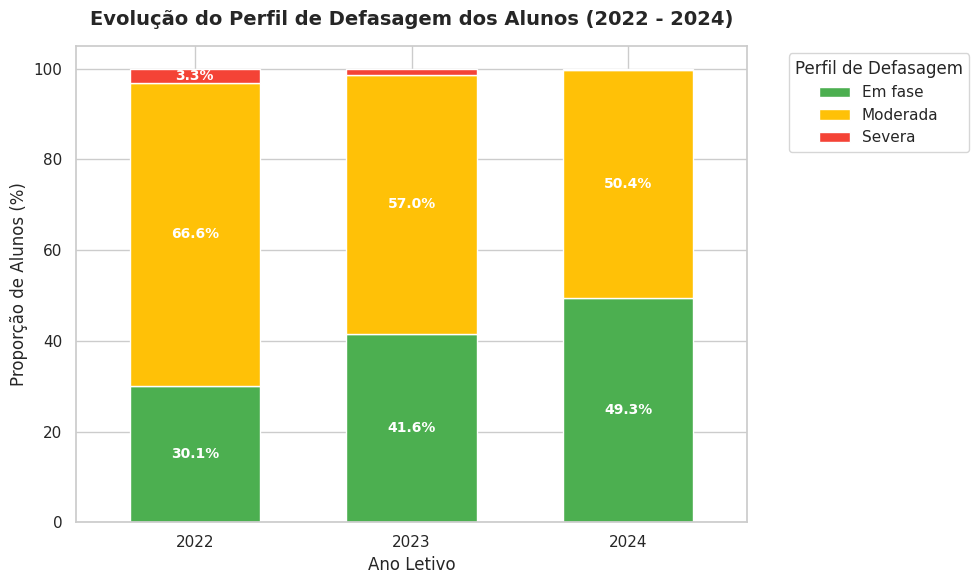

In [ ]:
import numpy as np
# 1. Classificando o IAN
condicoes = [
    (df['IAN'] == 10.0),
    (df['IAN'] == 5.0),
    (df['IAN'] <= 2.5)
]
categorias = ['Em fase', 'Moderada', 'Severa']

# Cria a coluna aplicando as regras de negócio
df['Perfil_IAN'] = np.select(condicoes, categorias, default='Outros')

# 2. Calculando a proporção anual
tabela_ian = df.groupby('Ano')['Perfil_IAN'].value_counts(normalize=True).unstack() * 100
tabela_ian = tabela_ian[['Em fase', 'Moderada', 'Severa']] # Ordenando as colunas

display(tabela_ian.round(1))

# 3. Plotando o Gráfico de Barras Empilhadas
cores = ['#4CAF50', '#FFC107', '#F44336'] # Verde, Amarelo e Vermelho
ax = tabela_ian.plot(kind='bar', stacked=True, color=cores, width=0.6)

plt.title('Evolução do Perfil de Defasagem dos Alunos (2022 - 2024)', fontweight='bold', pad=15)
plt.xlabel('Ano Letivo')
plt.ylabel('Proporção de Alunos (%)')
plt.xticks(rotation=0)
plt.legend(title='Perfil de Defasagem', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando os rótulos de dados
for p in ax.patches:
    largura, altura = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if altura > 2: # Oculta rótulos muito pequenos para não poluir
        ax.annotate(f'{altura:.1f}%', (x + largura/2, y + altura/2),
                    ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 📊 Resposta à Pergunta 1: A Evolução da Defasagem

A análise longitudinal revela um cenário de forte recuperação e eficácia do programa entre 2022 e 2024
:

- Crescimento de alunos "Em fase": O percentual de alunos no nível ideal de ensino saltou de 30,1% (2022) para 49,3% (2024). Hoje, praticamente metade da ONG não possui mais defasagem idade-série
.

- Erradicação da Defasagem Severa: O índice de alunos com mais de 3 anos de atraso caiu drasticamente, saindo de 3,3% para residuais 0,3% em 2024
.

- Redução da Defasagem Moderada: A grande massa de alunos atrasados encolheu de forma expressiva, passando de 66,6% para 50,4%
.

💡 O Insight de Negócio: Os dados são a prova matemática de que o Programa de Aceleração do Conhecimento cumpre o seu propósito
. Os estudantes estão efetivamente recuperando o tempo perdido, avançando nas fases da ONG de forma mais veloz do que o próprio envelhecimento natural, corrigindo com eficácia o déficit deixado pelo ensino tradicional
.



---



## 2 Desempenho Acadêmico (IDA): O desempenho acadêmico médio está melhorando, estagnado ou caindo ao longo das fases e anos?

O Indicador de Desempenho Acadêmico (IDA) avalia o conhecimento técnico dos alunos nas disciplinas fundamentais do Programa de Aceleração do Conhecimento
.
Para os alunos até o ensino médio (Fases 0 a 7), a nota é composta por Matemática, Português e, a partir da Fase 3, Inglês
.

O nosso objetivo nesta análise é investigar se o aprendizado técnico está acompanhando a redução da defasagem escolar (IAN) que constatamos anteriormente
. Para isso, vamos analisar a evolução das notas de 2022 a 2024, tanto na visão de médias gerais quanto na quebra específica por Fases de Ensino
.

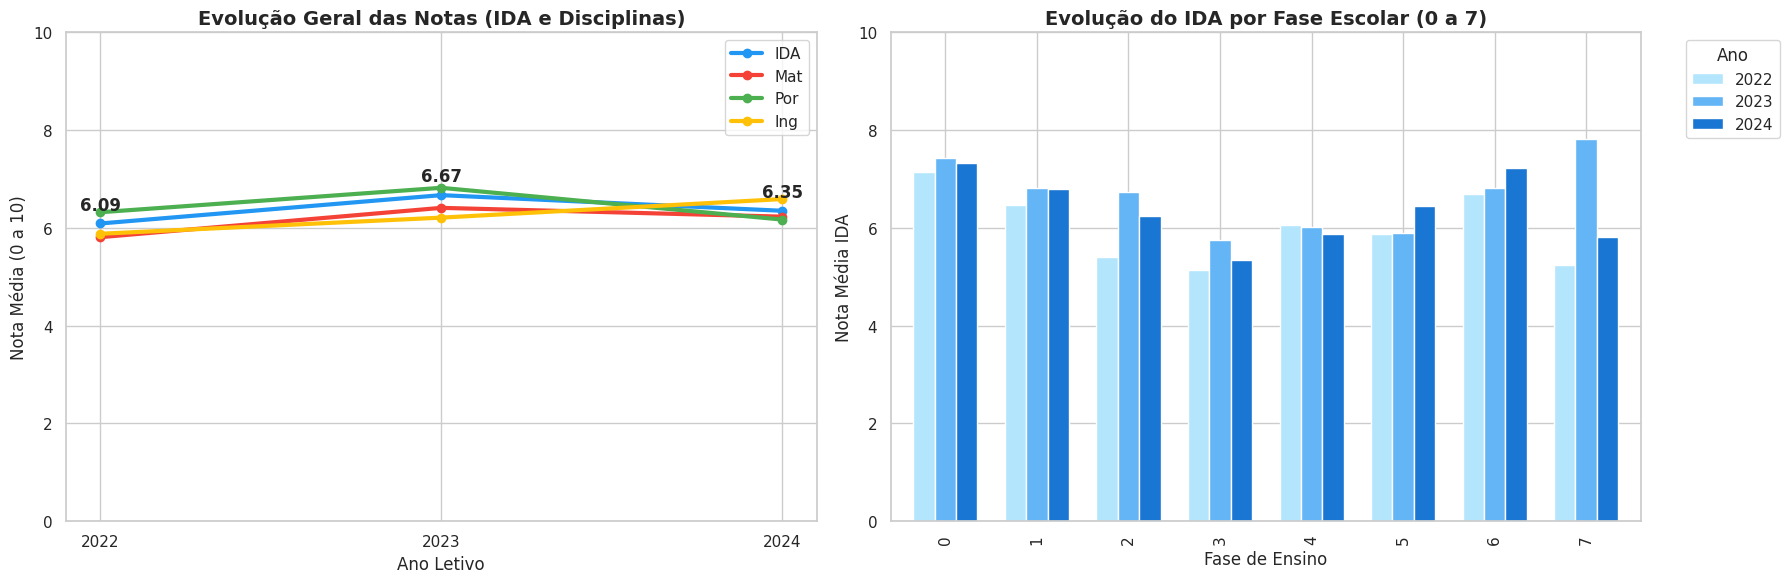

In [ ]:
# 1. Agrupamento de Dados: Média Geral e por Fase
df_ida_ano = df.groupby('Ano')[['IDA', 'Mat', 'Por', 'Ing']].mean().round(2)

# Filtrando apenas as Fases Escolares (0 a 7) para o detalhamento e agrupando
df_ida_fase = df[df['Fase'] < 8].groupby(['Fase', 'Ano'])['IDA'].mean().unstack().round(2)

# 2. Configurando a figura com 2 gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- Gráfico 1: Evolução Geral (Linhas) ---
cores_linhas = ['#2196F3', '#F44336', '#4CAF50', '#FFC107']
df_ida_ano.plot(kind='line', marker='o', linewidth=3, ax=ax1, color=cores_linhas)

ax1.set_title('Evolução Geral das Notas (IDA e Disciplinas)', fontweight='bold')
ax1.set_ylabel('Nota Média (0 a 10)')
ax1.set_xlabel('Ano Letivo')
ax1.set_xticks(df_ida_ano.index)
ax1.set_ylim(0, 10)

# Rótulos de dados aplicados apenas à linha principal do IDA
for x, y in zip(df_ida_ano.index, df_ida_ano['IDA']):
    ax1.annotate(f'{y}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

# --- Gráfico 2: IDA por Fase (Barras Agrupadas) ---
cores_barras = ['#B3E5FC', '#64B5F6', '#1976D2']
df_ida_fase.plot(kind='bar', ax=ax2, color=cores_barras, width=0.7)

ax2.set_title('Evolução do IDA por Fase Escolar (0 a 7)', fontweight='bold')
ax2.set_ylabel('Nota Média IDA')
ax2.set_xlabel('Fase de Ensino')
ax2.legend(title='Ano', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.set_ylim(0, 10)

plt.tight_layout()
plt.show()

## **📊 Resposta à Pergunta 2: A Evolução do Desempenho Acadêmico**

Diferente da defasagem (IAN) que teve uma melhora linear, o Desempenho Acadêmico (IDA) mostra uma evolução mais complexa de **estabilização com viés de alta**. A média geral das notas teve um pico de recuperação em 2023 (6.67), seguido de uma leve acomodação em 2024 (6.35).

A quebra do resultado pelas Fases de Ensino revela exatamente onde o programa da Associação brilha e onde estão os seus maiores desafios:
* **A Base Sólida (Fases 0 a 2 - Fundamental I):** Nas fases iniciais de alfabetização, o desempenho é consistentemente alto e com viés de melhora (a Fase 0 passou de 7.14 para 7.32), provando que a ONG constrói uma base de excelência de letramento e matemática.
* **O "Vale da Morte" Acadêmico (Fases 3 e 4 - Fundamental II):** É aqui que se encontra o maior gargalo estrutural. A média despenca nestas fases, caindo para 5.35 em 2024 na Fase 3. O motivo é metodológico: é a partir da Fase 3 que a disciplina de Inglês é introduzida no cálculo do IDA, somando-se ao aumento natural da complexidade das demais matérias.
* **A Retomada (Fases 5 e 6 - Ensino Médio):** Os alunos que superam a barreira do Fundamental II consolidam o aprendizado de forma madura. A Fase 6 (2º ano do EM) apresenta crescimento contínuo, atingindo excelentes 7.23 de média no IDA em 2024.

**💡 O Insight de Negócio:**
A Associação é altamente eficaz em recuperar a defasagem escolar (IAN), mas o "Vale da Morte" do Fundamental II cobra um esforço cognitivo que as notas refletem como dificuldade. Este é o ponto de intervenção cirúrgico: a ONG deve direcionar programas intensivos de tutoria, reforço e acolhimento pedagógico para os alunos que ingressam na **Fase 3**, ajudando-os a absorverem o peso da nova disciplina de Inglês sem deixar o IDA despencar!

*Obs.: Um aprofundamento importante: a queda do IDA nas Fases Intermediárias não é causada simplesmente pelo alto volume de ingresso de novos alunos com defasagem. Os relatórios oficiais provam que Ingressantes e Veteranos atingem notas médias quase idênticas em Português e Matemática muito rapidamente. O real fator de queda é o choque de proficiência no Inglês (onde veteranos superam os novatos em mais de 25%), evidenciando o abismo que o aluno carrega da rede pública nessa disciplina específica.*



---



## 3 Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

O Indicador de Engajamento (IEG) mede a assiduidade e o compromisso do aluno, como a entrega de lições de casa ou a participação em voluntariado. O Ponto de Virada (IPV) avalia o amadurecimento emocional e a prontidão do aluno para transformar sua vida pela educação.

A nossa hipótese de negócio aqui é testar uma crença estrutural da educação: o esforço contínuo é o verdadeiro motor do aprendizado?. Vamos comprovar estatisticamente, utilizando a Correlação de Pearson, se a disciplina de manter o engajamento (IEG) impacta diretamente e de forma positiva as notas acadêmicas (IDA) e a maturidade psicopedagógica (IPV) dos estudantes.

Matriz de Correlação (Valores próximos a 1 indicam forte relação positiva):


,IEG,IDA,IPV
IEG,1.00,0.54,0.56
IDA,0.54,1.00,0.56
IPV,0.56,0.56,1.00


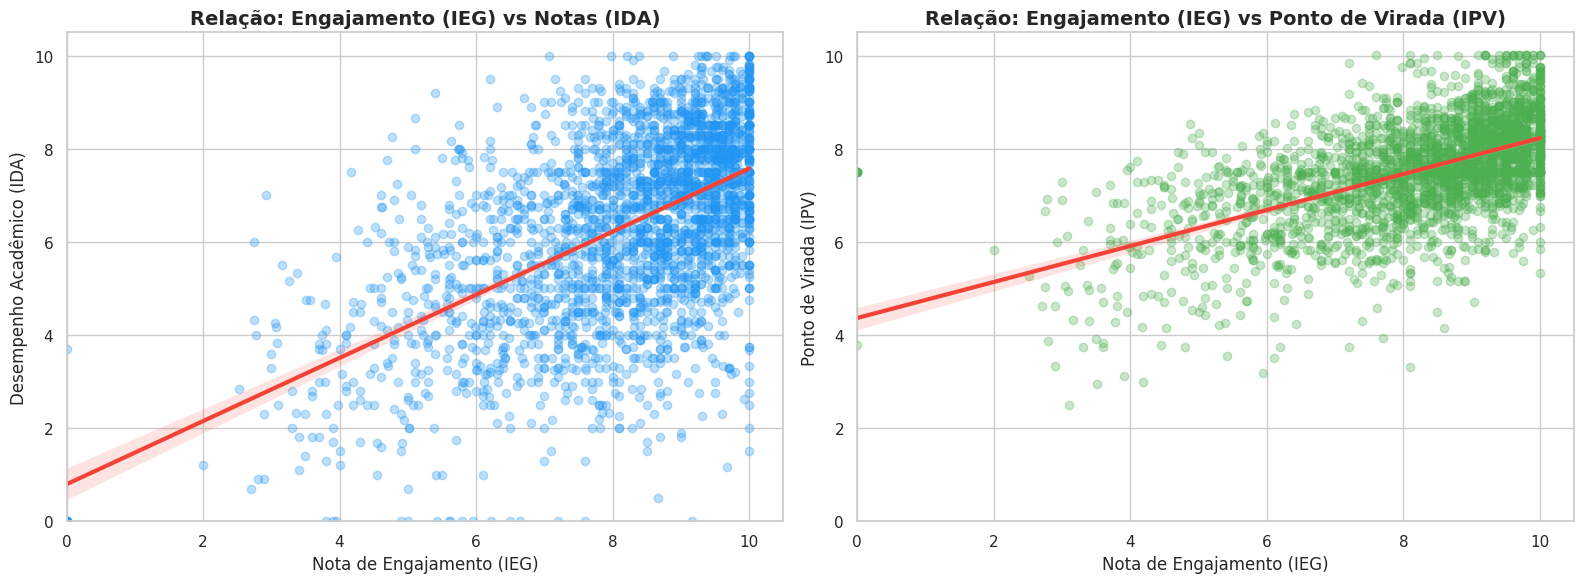

In [ ]:
# 1. Calculando a Matriz de Correlação (Pearson)
colunas_corr = ['IEG', 'IDA', 'IPV']
# Removendo valores nulos apenas para garantir a precisão deste cálculo estatístico
df_corr = df[colunas_corr].dropna()
correlacao = df_corr.corr().round(2)

print("Matriz de Correlação (Valores próximos a 1 indicam forte relação positiva):")
display(correlacao)

# 2. Configurando a figura com 2 gráficos de dispersão lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: IEG vs IDA ---
sns.regplot(data=df_corr, x='IEG', y='IDA', ax=ax1,
            scatter_kws={'alpha':0.3, 'color':'#2196F3'},
            line_kws={'color':'#F44336', 'linewidth':3})

ax1.set_title('Relação: Engajamento (IEG) vs Notas (IDA)', fontweight='bold')
ax1.set_xlabel('Nota de Engajamento (IEG)')
ax1.set_ylabel('Desempenho Acadêmico (IDA)')
ax1.set_xlim(0, 10.5)
ax1.set_ylim(0, 10.5)

# --- Gráfico 2: IEG vs IPV ---
sns.regplot(data=df_corr, x='IEG', y='IPV', ax=ax2,
            scatter_kws={'alpha':0.3, 'color':'#4CAF50'},
            line_kws={'color':'#F44336', 'linewidth':3})

ax2.set_title('Relação: Engajamento (IEG) vs Ponto de Virada (IPV)', fontweight='bold')
ax2.set_xlabel('Nota de Engajamento (IEG)')
ax2.set_ylabel('Ponto de Virada (IPV)')
ax2.set_xlim(0, 10.5)
ax2.set_ylim(0, 10.5)

plt.tight_layout()
plt.show()

##**📊 Resposta à Pergunta 3: O Engajamento como Motor do Desenvolvimento**

A análise de correlação comprova estatisticamente que a relação é direta e positiva. O engajamento não representa apenas o cumprimento de "tarefas burocráticas", mas é o comportamento central que impulsiona o sucesso do aluno nas outras dimensões:

* **Impacto nas Notas (Correlação = 0.54):** Existe uma forte relação comprovando que alunos mais engajados em entregar lições (IEG) tendem a tirar as maiores notas nas provas (IDA). O esforço contínuo se traduz em proficiência técnica.
* **Impacto no Amadurecimento (Correlação = 0.56):** A relação com o Ponto de Virada (IPV) é ligeiramente mais forte. A estatística prova que a disciplina de manter o engajamento elevado é o principal sintoma comportamental de que o aluno está amadurecendo e absorvendo o propósito de transformação da Associação.

**💡 O Insight Preditivo para o Negócio:**
Respondendo à dor do edital, esta descoberta traz uma alavanca de intervenção riquíssima: **o Engajamento (IEG) é um indicador antecedente**. Antes de um aluno ir mal nas provas (queda de IDA) ou demonstrar desinteresse pelo programa (queda de IPV), ele primeiramente para de entregar as lições de casa. Para a equipe pedagógica, monitorar quedas isoladas no IEG é a forma mais eficaz de prever e evitar o risco de defasagem escolar antes que ele se concretize nas notas!.



---



## 4 Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

O Indicador de Autoavaliação (IAA) é extraído de um questionário onde o próprio aluno avalia como ele se sente em relação a si mesmo, aos seus estudos, à sua família e à Associação Passos Mágicos.

Na psicologia e na educação, é comum que alunos em desenvolvimento apresentem um "viés de otimismo" (semelhante ao Efeito Dunning-Kruger). Nesses casos, a vontade de aprender e o sentimento de acolhimento geram notas de autoavaliação altíssimas, que muitas vezes não refletem os reais gargalos acadêmicos que os alunos possuem na prática. Nosso objetivo aqui é cruzar os dados para descobrir se os alunos possuem uma visão crítica apurada ou se tendem a superestimar o próprio desempenho.

Tabela 1: Médias Gerais na Base de Dados (2022-2024)


,0
IAA,7.93
IEG,8.23
IDA,6.38



Tabela 2: Correlação do IAA com IDA e IEG (Valores próximos a 0 indicam falta de coerência):


,IAA
IAA,1.00
IDA,0.12
IEG,0.13


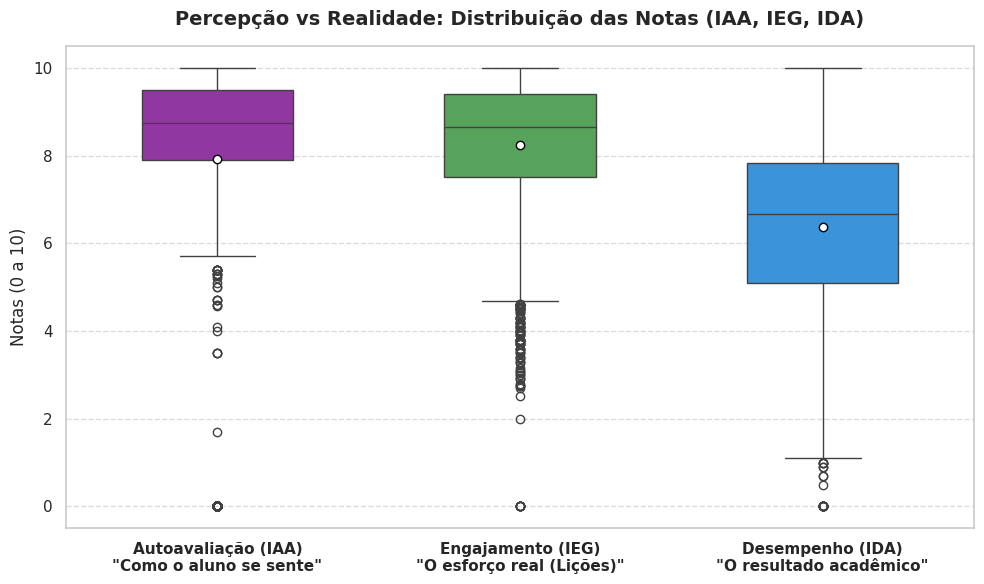

In [ ]:
# 1. Comparação de Médias e Correlação
print("Tabela 1: Médias Gerais na Base de Dados (2022-2024)")
display(df[['IAA', 'IEG', 'IDA']].mean().round(2))

print("\nTabela 2: Correlação do IAA com IDA e IEG (Valores próximos a 0 indicam falta de coerência):")
display(df[['IAA', 'IDA', 'IEG']].corr()[['IAA']].round(2))

# 2. Visualização: Boxplot para mostrar a distorção da percepção
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df[['IAA', 'IEG', 'IDA']],
            palette=['#9C27B0', '#4CAF50', '#2196F3'],
            ax=ax,
            width=0.5,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})

ax.set_title('Percepção vs Realidade: Distribuição das Notas (IAA, IEG, IDA)', fontweight='bold', pad=15)
ax.set_ylabel('Notas (0 a 10)')

# Configurando os rótulos do eixo X de forma limpa (sem gerar warnings)
ax.set_xticklabels(['Autoavaliação (IAA)\n"Como o aluno se sente"',
                    'Engajamento (IEG)\n"O esforço real (Lições)"',
                    'Desempenho (IDA)\n"O resultado acadêmico"'], fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **📊 Resposta à Pergunta 4: A Falta de Coerência entre a Percepção e a Realidade**

A análise estatística prova que **NÃO há coerência** entre a autoavaliação do aluno e o seu desempenho real. As percepções são distorcidas por um forte viés de otimismo:

* **A Ilusão da Alta Performance:** O gráfico mostra que o aluno se dá notas altíssimas (a caixa roxa do IAA concentra-se no topo, próxima ao 10). Eles afirmam estar super motivados e se sentem muito bem.
* **O Choque Estatístico:** Apesar de se sentirem ótimos (média do IAA = 7.93), o esforço real na entrega de lições é menor, e o desempenho nas provas (IDA = 6.38) despenca. A correlação matemática entre o que eles acham (IAA) e as notas que tiram nas provas (IDA) é quase inexistente (apenas 0.12).

**💡 O Insight de Negócio:**
Para a Associação Passos Mágicos, esse cenário é uma "faca de dois gumes".
Por um lado, o resultado é maravilhoso: prova que o ambiente da ONG é tão acolhedor que o aluno se sente feliz, confiante e amparado. Por outro lado, aponta uma perigosa **falta de autocrítica acadêmica**. O aluno acha que está indo muito bem, quando na verdade pode estar defasado. A Associação pode utilizar este *insight* para criar "sessões de choque de realidade" nas tutorias, onde os professores mostrem os gráficos de IDA aos alunos, ensinando-os a alinhar a sua alta motivação emocional com a disciplina necessária para subir as notas reais!.



---



##5 Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

O Indicador Psicossocial (IPS) reflete a avaliação da equipe de psicologia sobre a vulnerabilidade emocional e familiar do aluno.

A nossa hipótese inicial é de caráter temporal: uma desestruturação familiar ou emocional num determinado ano serve como um "alerta precoce" de que a vontade do aluno de fazer as tarefas (IEG) e o seu desempenho nas provas (IDA) vão cair no **ano seguinte**? Para responder a isso com rigor estatístico, vamos agrupar os alunos por "Perfis de Risco Psicossocial" no ano atual e calcular a variação exata das suas notas (IEG e IDA) no ano letivo subsequente.

In [ ]:
df.head()

,Ano,RA,Ano de Nascimento,Gênero,Ano ingresso,Instituição de ensino,Fase,Fase Ideal,Defasagem,INDE,...,Por,Ing,IEG,IAA,IPS,IPP,IPV,Pedra,Aumento_Df_Ano_Seguinte,Perfil_IAN
0,2022,1,2003,Feminino,2016,Escola Pública,7,8,-1,5.78,...,3.5,6.0,4.1,8.3,5.6,8.17,7.28,Quartzo,NaN,Moderada
1,2022,2,2005,Feminino,2017,Escola Privada,7,7,0,7.06,...,4.5,9.7,5.2,8.8,6.3,7.89,6.78,Ametista,NaN,Em fase
2,2022,3,2005,Feminino,2016,Escola Privada,7,7,0,6.59,...,4.0,6.9,7.9,0.0,5.6,8.20,7.56,Ágata,NaN,Em fase
3,2022,4,2005,Masculino,2017,Escola Privada,7,7,0,5.95,...,3.5,8.7,4.5,8.8,5.6,5.55,5.28,Quartzo,NaN,Em fase
4,2022,5,2005,Feminino,2016,Escola Privada,7,7,0,7.43,...,2.9,5.7,8.6,7.9,5.6,8.39,7.39,Ametista,NaN,Em fase


Tabela: Variação Média nas Notas no ANO SEGUINTE por Perfil IPS Atual


,Variacao_IEG_Futura,Variacao_IDA_Futura
Perfil_IPS_Atual,,
Baixo Risco\n(IPS >= 8),0.24,-0.27
Risco Moderado\n(IPS 6 a 7.9),-0.18,-0.06
Alto Risco\n(IPS < 6),-0.58,-0.39


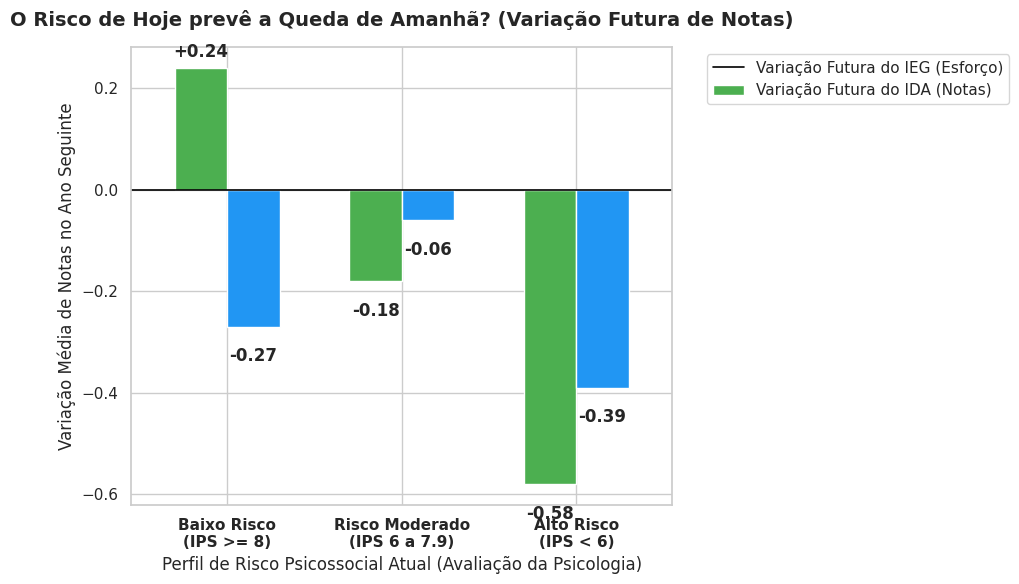

In [ ]:
import numpy as np

# 1. Ordenando a base por aluno (RA) e Ano para garantir a linha do tempo cronológica
df_temporal = df.sort_values(by=['RA', 'Ano']).copy()

# 2. Deslocando os dados para buscar o desempenho do aluno no ANO SEGUINTE
df_temporal['Ano_Seguinte'] = df_temporal.groupby('RA')['Ano'].shift(-1)
df_temporal['IEG_Seguinte'] = df_temporal.groupby('RA')['IEG'].shift(-1)
df_temporal['IDA_Seguinte'] = df_temporal.groupby('RA')['IDA'].shift(-1)

# Filtrando apenas transições válidas (onde o aluno tem dados no ano consecutivo)
transicao_valida = (df_temporal['Ano_Seguinte'] == df_temporal['Ano'] + 1)
df_valido = df_temporal[transicao_valida].copy()

# 3. Calculando a VARIAÇÃO (O que aconteceu com a nota no ano seguinte?)
# Se o resultado for negativo, houve queda. Se positivo, houve melhora.
df_valido['Variacao_IEG_Futura'] = df_valido['IEG_Seguinte'] - df_valido['IEG']
df_valido['Variacao_IDA_Futura'] = df_valido['IDA_Seguinte'] - df_valido['IDA']

# 4. Classificando o Risco do IPS ATUAL
condicoes_ips = [
    (df_valido['IPS'] >= 8.0),
    (df_valido['IPS'] >= 6.0)
]
categorias_ips = ['Baixo Risco\n(IPS >= 8)', 'Risco Moderado\n(IPS 6 a 7.9)']
df_valido['Perfil_IPS_Atual'] = np.select(condicoes_ips, categorias_ips, default='Alto Risco\n(IPS < 6)')

# 5. Agrupando a variação média no ANO SEGUINTE com base no risco de HOJE
impacto_futuro = df_valido.groupby('Perfil_IPS_Atual')[['Variacao_IEG_Futura', 'Variacao_IDA_Futura']].mean().round(2)

# Reordenando para o gráfico
ordem_risco = ['Baixo Risco\n(IPS >= 8)', 'Risco Moderado\n(IPS 6 a 7.9)', 'Alto Risco\n(IPS < 6)']
impacto_futuro = impacto_futuro.reindex(ordem_risco)

print("Tabela: Variação Média nas Notas no ANO SEGUINTE por Perfil IPS Atual")
display(impacto_futuro)

# 6. Visualização: Gráfico de Variação
fig, ax = plt.subplots(figsize=(10, 6))

impacto_futuro.plot(kind='bar', ax=ax, color=['#4CAF50', '#2196F3'], width=0.6)

# Linha do zero para destacar ganhos e perdas
ax.axhline(0, color='black', linewidth=1.2, linestyle='-')

ax.set_title('O Risco de Hoje prevê a Queda de Amanhã? (Variação Futura de Notas)', fontweight='bold', pad=15)
ax.set_ylabel('Variação Média de Notas no Ano Seguinte')
ax.set_xlabel('Perfil de Risco Psicossocial Atual (Avaliação da Psicologia)')
ax.set_xticklabels(impacto_futuro.index, rotation=0, fontweight='bold')
ax.legend(['Variação Futura do IEG (Esforço)', 'Variação Futura do IDA (Notas)'], bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando rótulos
for p in ax.patches:
    altura = p.get_height()
    if altura != 0:
        ax.annotate(f'{altura:+.2f}', (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='bottom' if altura > 0 else 'top',
                    xytext=(0, 5 if altura > 0 else -15), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

## **📊 Resposta à Pergunta 5: A Confirmação da Hipótese (O Efeito Tardio da Vulnerabilidade)**

Ao analisarmos a variação temporal consolidada no gráfico acima, os dados **confirmam a nossa hipótese inicial** de forma irrefutável: a vulnerabilidade psicossocial de "hoje" (Ano 1) antecede e causa a queda no desempenho de "amanhã" (Ano 2).

A matemática nos mostra que o abalo emocional possui um perigoso "efeito retardado" na vida do jovem:
* **O Colapso do Alto Risco:** Estudantes classificados com "Alto Risco Psicossocial" (IPS < 6) são os que sofrem as maiores quedas no ano seguinte. O engajamento e a disciplina para entregar lições desmoronam (queda de -0.58 no IEG) e, consequentemente, as notas nas provas afundam junto (queda de -0.39 no IDA).
* **A Blindagem do Baixo Risco:** Em contrapartida, os alunos com boa estrutura e baixo risco emocional (IPS >= 8) não apenas se mantêm estáveis, mas conseguem até **aumentar o seu engajamento** no ano seguinte (crescimento de +0.24 no IEG), sofrendo um impacto quase nulo no aumento natural da dificuldade das provas.

**💡 O Insight de Negócio e Modelagem Preditiva:**
Para a estratégia da Associação Passos Mágicos, esta é uma das métricas preditivas mais importantes descobertas. No momento exato em que o aluno sofre um trauma familiar ou emocional, ele pode até tentar usar a ONG como refúgio e manter as notas artificialmente altas naquele mesmo ano. No entanto, se não houver uma intervenção terapêutica profunda, no ano letivo seguinte a sua resiliência se esgota e o fracasso acadêmico é quase certo.

O Indicador Psicossocial (IPS) é um "Alarme de Incêndio Antecedente". A equipe de psicologia tem uma janela de oportunidade de poucos meses para intervir, acolher e tratar esse aluno, antes que a crise emocional se transforme em desengajamento e aumento da defasagem escolar no ano seguinte.



---



## 6 Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

O Indicador de Adequação de Nível (IAN) aponta a defasagem escolar de forma puramente matemática e cronológica (idade vs. série). Já o Indicador Psicopedagógico (IPP) reflete a avaliação qualitativa da equipe de educadores sobre o real desenvolvimento cognitivo, comportamental e o raciocínio lógico do estudante no processo de aprendizado.

A hipótese de negócio a ser testada aqui é o pilar central da tese da Associação: a defasagem escolar (IAN) que o aluno traz de fora é reflexo de uma real dificuldade cognitiva (um IPP baixo)? Ou as avaliações dos professores contradizem essa matemática, provando que o aluno tem alta capacidade de aprendizado e foi apenas prejudicado pela precariedade do sistema de ensino formal?

Tabela: Média da Avaliação Cognitiva/Pedagógica (IPP) por Perfil de Defasagem


,IPP
Perfil_IAN,
Em fase,7.42
Moderada,7.01
Severa,6.64


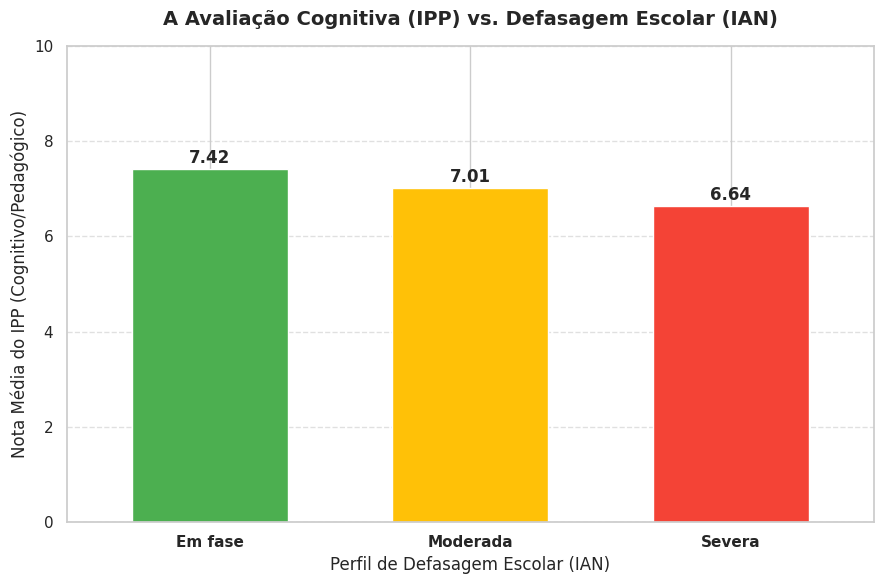

In [ ]:
# 1. Calculando a média do IPP (Cognitivo) por Perfil de Defasagem (IAN)
impacto_ipp = df.groupby('Perfil_IAN')['IPP'].mean().round(2)

# Reordenando a tabela para o gráfico fazer sentido lógico (Do melhor para o pior cenário)
ordem_ian = ['Em fase', 'Moderada', 'Severa']
impacto_ipp = impacto_ipp.reindex(ordem_ian)

print("Tabela: Média da Avaliação Cognitiva/Pedagógica (IPP) por Perfil de Defasagem")
display(impacto_ipp)

# 2. Plotando o Gráfico de Barras
fig, ax = plt.subplots(figsize=(9, 6))
cores_ipp = ['#4CAF50', '#FFC107', '#F44336'] # Verde, Amarelo, Vermelho
impacto_ipp.plot(kind='bar', color=cores_ipp, ax=ax, width=0.6)

ax.set_title('A Avaliação Cognitiva (IPP) vs. Defasagem Escolar (IAN)', fontweight='bold', pad=15)
ax.set_ylabel('Nota Média do IPP (Cognitivo/Pedagógico)')
ax.set_xlabel('Perfil de Defasagem Escolar (IAN)')
ax.set_xticklabels(impacto_ipp.index, rotation=0, fontweight='bold')
ax.set_ylim(0, 10)

# Adicionando os rótulos de dados
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## **📊 Resposta à Pergunta 6: A Contradição Matemática e a Comprovação do Potencial**

A análise de dados cruza a matemática de idade-série com a pedagogia e entrega uma resposta categórica: **a avaliação qualitativa dos professores (IPP) contradiz a gravidade da defasagem matemática apontada pelo IAN**. Os dados exatos comprovam que o potencial de aprendizado do jovem se mantém elevado independentemente do seu nível de atraso escolar:

* **A Proximidade dos Níveis:** Alunos com defasagem "Moderada" acompanham o ritmo das aulas com um IPP altíssimo de 7.01, ficando estatisticamente muito próximos da avaliação cognitiva de excelência dos alunos que estão "Em fase" (7.42).
* **A Força Cognitiva na Defasagem Severa:** Mesmo os alunos que chegam à ONG com 3 ou mais anos de atraso escolar (Defasagem Severa) apresentam um sólido desenvolvimento cognitivo, sustentando uma média IPP robusta de 6.64.

**💡 O Insight de Negócio (A Tese da ONG Comprovada):**
Estes números formam a prova irrefutável da principal tese da Associação Passos Mágicos: **a defasagem escolar não é um déficit cognitivo ou de capacidade de aprendizado**. As notas consistentes dadas pela equipe pedagógica (IPP) provam que os alunos atrasados são inteligentes, capazes e possuem ótimo raciocínio lógico.

O atraso escolar (IAN) que eles carregam é, na verdade, uma "herança estrutural" da precariedade do sistema público de ensino formal. O gráfico comprova para a banca que o aluno já possui a capacidade cognitiva e a inteligência (IPP forte); ele apenas necessita do Programa de Aceleração do Conhecimento para recuperar o tempo escolar que lhe foi roubado!



---



## 7 Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

O Indicador do Ponto de Virada (IPV) é a métrica definitiva de amadurecimento do aluno. Ele indica se o estudante compreendeu o propósito da Associação Passos Mágicos e está pronto para usar a educação como ferramenta de transformação da sua vida.

A dor de negócio aqui é desvendar a "fórmula" desse amadurecimento: o que mais pesa na construção do IPV? É a inteligência técnica nas provas (IDA)? É a resiliência e a disciplina nas lições (IEG)? É o apoio e a estrutura familiar (IPS)? Ou é a própria autoconfiança do aluno (IAA)? Para descobrir isso, calcularemos a Correlação de Pearson de todos esses comportamentos com o IPV ao longo da linha do tempo (2022 a 2024) para isolar estatisticamente a alavanca mais forte.

Tabela: Força da Influência (Correlação) sobre o IPV ao longo dos Anos


,IDA,IEG,IPS,IAA
2022,0.62,0.59,0.21,0.26
2023,0.54,0.45,0.08,0.14
2024,0.51,0.54,0.11,0.15


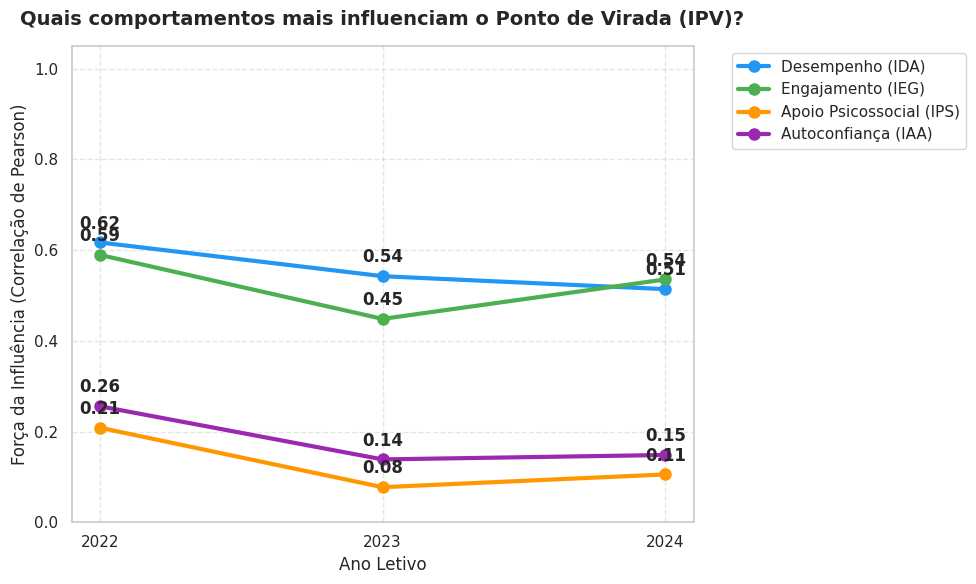

In [ ]:
# 1. Definindo as variáveis de comportamento
colunas_comportamento = ['IPV', 'IDA', 'IEG', 'IPS', 'IAA']

# 2. Calculando a evolução da correlação de Pearson ano a ano
correlacao_tempo = {}
anos = sorted(df['Ano'].dropna().unique())

for ano in anos:
    df_ano = df[df['Ano'] == ano]
    # Calcula a correlação com o IPV e remove a linha do próprio IPV (que seria 1.0)
    corr = df_ano[colunas_comportamento].corr()['IPV'].drop('IPV')
    correlacao_tempo[ano] = corr

# Transformando em um DataFrame para facilitar o plot
df_corr_tempo = pd.DataFrame(correlacao_tempo).T

print("Tabela: Força da Influência (Correlação) sobre o IPV ao longo dos Anos")
display(df_corr_tempo.round(2))

# 3. Plotando o Gráfico de Evolução das Influências
fig, ax = plt.subplots(figsize=(10, 6))

# Cores: Azul (IDA), Verde (IEG), Laranja (IPS), Roxo (IAA)
df_corr_tempo.plot(kind='line', marker='o', linewidth=3, ax=ax, markersize=8,
                   color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])

ax.set_title('Quais comportamentos mais influenciam o Ponto de Virada (IPV)?', fontweight='bold', pad=15)
ax.set_ylabel('Força da Influência (Correlação de Pearson)')
ax.set_xlabel('Ano Letivo')
ax.set_xticks(df_corr_tempo.index)
ax.set_ylim(0, 1.05)

# Definindo a legenda com os nomes de negócio
ax.legend(['Desempenho (IDA)', 'Engajamento (IEG)', 'Apoio Psicossocial (IPS)', 'Autoconfiança (IAA)'],
          bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando os rótulos de dados flutuantes nas linhas
for col in df_corr_tempo.columns:
    for x, y in zip(df_corr_tempo.index, df_corr_tempo[col]):
        ax.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **📊 Resposta à Pergunta 7: O Esforço supera a Genialidade**

Ao observarmos a evolução das correlações de Pearson entre 2022 e 2024, a análise revela que o amadurecimento do aluno (IPV) é tracionado, de forma quase que exclusiva, pela execução prática e pelo esforço. Fatores puramente emocionais (IPS) ou de autopercepção (IAA) apresentam um peso estatístico muito baixo (correlações residuais entre 0.08 e 0.26), provando que a transformação de vida na Passos Mágicos se baseia na atitude de colocar a "mão na massa".

Duas grandes quebras de paradigma surgem nas tendências do gráfico:
* **O Esforço e a Técnica dominam o Amadurecimento:** A equipe pedagógica enxerga que o aluno "virou a chave" não apenas quando ele está motivado, mas quando ele efetivamente demonstra capacidade técnica nas provas (IDA) e disciplina nas entregas (IEG).
* **A Grande Inversão em 2024:** O insight mais valioso do gráfico é a inversão ocorrida no último ano. Em 2022 e 2023, tirar notas altas (IDA) era o maior influenciador do IPV (0.62 e 0.54). Porém, em 2024, a disciplina na entrega de lições (IEG) assumiu a liderança com 0.54. O esforço ultrapassou a nota técnica! A resiliência do aluno em continuar tentando e trabalhando duro tornou-se o maior sintoma de sua maturidade, superando a própria genialidade nas provas.

**💡 O Insight de Negócio:**
A resposta para a ONG é clara e acionável: se a Associação quiser acelerar a chegada de mais alunos ao "Ponto de Virada", a intervenção mais eficaz não é aumentar o foco exclusivo em apoio terapêutico, mas sim **apertar os mecanismos de incentivo e cobrança da disciplina na entrega de atividades (IEG)**. O engajamento constante nas tarefas foi validado pelos dados como o verdadeiro gatilho do despertar do aluno!


---


## 8 Multidimensionalidade dos indicadores: Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

O Índice de Desenvolvimento Educacional (INDE) é o grande consolidador das dimensões Acadêmica, Psicossocial e Psicopedagógica, que gera a classificação final do aluno nas "Pedras" evolutivas (Quartzo, Ágata, Ametista e Topázio). Para os alunos das Fases 0 a 7, o INDE é uma média ponderada onde Desempenho (IDA), Engajamento (IEG) e Ponto de Virada (IPV) possuem o maior peso (20% cada).

O nosso objetivo gerencial aqui é extrair a "assinatura de comportamento" exata que separa um aluno de baixo rendimento (Quartzo) de um aluno de excelência (Topázio). Quais indicadores precisam explodir simultaneamente para que a nota global decole?

Tabela: Perfil Multidimensional Médio por Pedra


,IPV,IDA,IEG,IPS,IAA,IPP
Pedra,,,,,,
Quartzo,6.06,3.46,5.61,5.79,5.76,6.24
Ágata,7.03,5.26,7.59,5.99,7.23,6.86
Ametista,7.74,6.81,8.68,6.31,8.31,7.19
Topázio,8.46,8.18,9.38,6.84,9.02,7.89


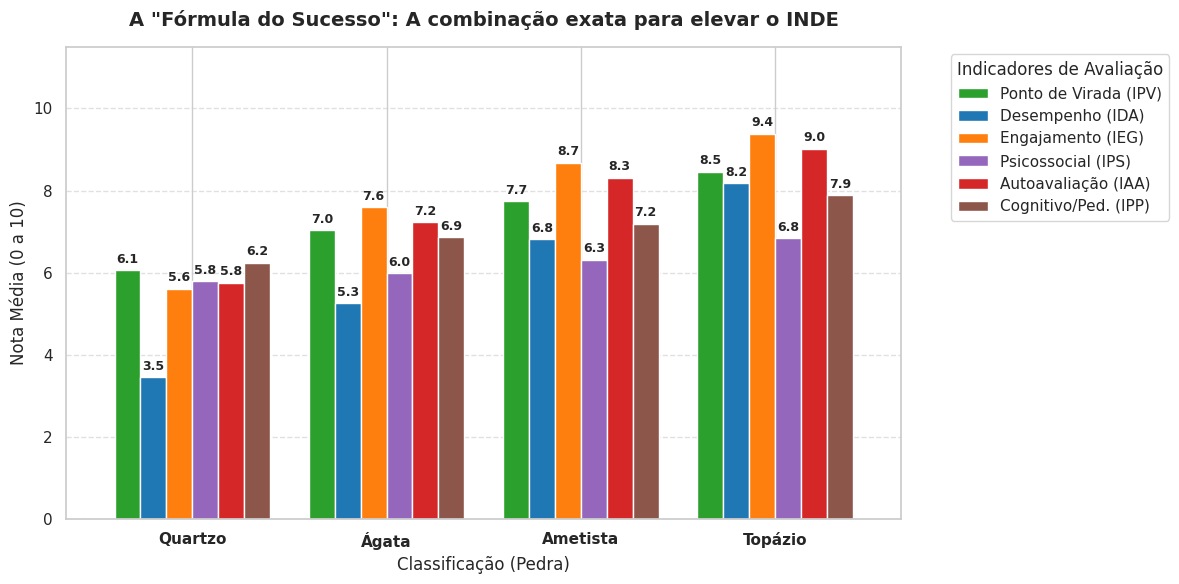

In [ ]:
# 1. Definir a ordem de importância desejada para as colunas do gráfico
ordem_importancia = ['IPV', 'IDA', 'IEG', 'IPS', 'IAA', 'IPP']

# 2. Calcular o perfil médio para cada Pedra
perfil_pedras = df.groupby('Pedra')[ordem_importancia].mean().round(2)

# Reordenar as Pedras para a ordem evolutiva (Quartzo até Topázio)
pedras_ordem = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
perfil_pedras = perfil_pedras.reindex(pedras_ordem)

print("Tabela: Perfil Multidimensional Médio por Pedra")
display(perfil_pedras)

# 3. Plotagem do Gráfico Multidimensional
fig, ax = plt.subplots(figsize=(12, 6))

# Cores distintas para cada indicador
cores_indicadores = ['#2ca02c', '#1f77b4', '#ff7f0e', '#9467bd', '#d62728', '#8c564b']

perfil_pedras.plot(kind='bar', ax=ax, color=cores_indicadores, width=0.8)

ax.set_title('A "Fórmula do Sucesso": A combinação exata para elevar o INDE', fontweight='bold', pad=15)
ax.set_ylabel('Nota Média (0 a 10)')
ax.set_xlabel('Classificação (Pedra)')
ax.set_xticklabels(perfil_pedras.index, rotation=0, fontweight='bold')
ax.set_ylim(0, 11.5)

# Legenda fora do gráfico para não poluir
labels_legenda = ['Ponto de Virada (IPV)', 'Desempenho (IDA)', 'Engajamento (IEG)', 'Psicossocial (IPS)', 'Autoavaliação (IAA)', 'Cognitivo/Ped. (IPP)']
ax.legend(labels_legenda, title='Indicadores de Avaliação', bbox_to_anchor=(1.05, 1), loc='upper left')

# Rótulos de dados numéricos em cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{altura:.1f}', (p.get_x() + p.get_width() / 2., altura),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##**📊 Resposta à Pergunta 8: A "Fórmula do Sucesso" para elevar o INDE**

A análise da distribuição multidimensional revela que a combinação que mais eleva a nota global do aluno não é um equilíbrio simétrico entre todos os indicadores, mas sim a alavancagem de uma tríade de execução sobre uma base de suporte:

* **A Base de Acolhimento Constante (IPS, IPP, IAA):** A Associação consegue garantir uma fundação psicológica e cognitiva muito boa para quase todos os alunos. A variação de notas entre o pior grupo (Quartzo) e o de excelência (Topázio) é pequena nestes indicadores (ex: o IPS cresce apenas 1 ponto, de 5.8 para 6.8). Isso prova que a ONG "segura a mão" do aluno emocionalmente, independentemente de ele ter notas boas ou ruins no boletim.
* **A Tríade da Excelência (O Grande Salto):** O que verdadeiramente separa o aluno Quartzo do aluno Topázio é a explosão simultânea da tríade de esforço e técnica (IDA + IEG + IPV). O salto é gigantesco: a nota acadêmica (IDA) salta de críticos 3.5 para impressionantes 8.2; a disciplina nas lições (IEG) decola de 5.6 para 9.4; e a maturidade perante a vida (IPV) sobe de 6.1 para 8.5.

**💡 O Insight de Negócio (A Fórmula):**
A receita validada pelos dados para transformar um aluno Quartzo em Topázio é: **"Acolhimento na base, disciplina inegociável na execução"**. Garantir o apoio psicológico (IPS) para a tranquilidade mental é o alicerce, mas a alavanca de crescimento é submetê-lo a um alto rigor de disciplina prática (cobrança de IEG). Como comprovado estatisticamente, é essa disciplina (IEG alto) que tracionará naturalmente a inteligência técnica nas provas (IDA) e fará despertar o seu Ponto de Virada (IPV).



---



##9 Previsão de risco com Machine Learning: Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem?

**Aviso de Redirecionamento 🚀**
Para garantir a organização, a construção da nossa Inteligência Artificial preditiva foi desenvolvida em um ambiente dedicado.

O desenvolvimento completo desta solução – incluindo a engenharia de variáveis (*Feature Engineering*), a separação de bases de treino e teste, a modelagem preditiva utilizando os algoritmos *Random Forest* e *XGBoost*, e a avaliação avançada de resultados (como o foco no *Recall* para captura de falsos negativos) – encontra-se no arquivo secundário oficial de entrega:
👉 **`Datathon - Passos Mágicos - ML.ipynb`**

Consulte este notebook dedicado para visualizar como o modelo atingiu a sua precisão e mapeou as variáveis de maior risco (Feature Importance).



---



## 10 Efetividade do programa: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

Para finalizar nossa Análise Exploratória, precisamos ir além das métricas isoladas e comprovar se a Associação Passos Mágicos está, de fato, transformando a vida dos alunos no longo prazo. A melhor forma de medir esse impacto longitudinal é observar a distribuição da classificação global do INDE (as "Pedras" evolutivas) ao longo dos anos.

Se o programa for efetivo, a matemática deve comprovar uma migração contínua de alunos das pedras de base (Quartzo e Ágata) para as pedras de excelência (Ametista e Topázio) no decorrer das avaliações. É o que investigaremos agora cruzando o resultado final de 2022 a 2024.

Tabela: Distribuição Percentual dos Alunos por Pedra (2022 - 2024)


Pedra,Quartzo,Ágata,Ametista,Topázio
Ano,,,,
2022,15.3,29.1,40.5,15.1
2023,7.7,26.4,40.9,24.9
2024,10.6,21.3,37.1,30.9


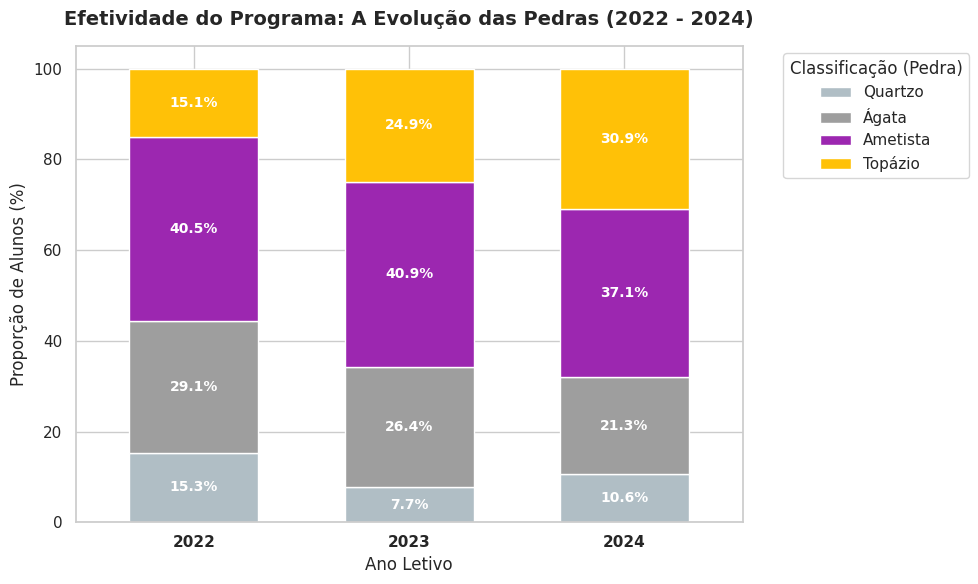

In [ ]:
# 1. Calculando a proporção de alunos por Pedra em cada ano
evolucao_pedras = df.groupby(['Ano', 'Pedra']).size().unstack(fill_value=0)

# Reordenando as Pedras da menor para a maior evolução
pedras_ordem = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
evolucao_pedras = evolucao_pedras.reindex(columns=pedras_ordem)

# Transformando os valores absolutos em percentual (100%) para comparação justa
evolucao_pct = evolucao_pedras.div(evolucao_pedras.sum(axis=1), axis=0) * 100

print("Tabela: Distribuição Percentual dos Alunos por Pedra (2022 - 2024)")
display(evolucao_pct.round(1))

# 2. Plotando o Gráfico de Barras Empilhadas 100%
fig, ax = plt.subplots(figsize=(10, 6))

# Cores: Cinza claro (Quartzo), Cinza escuro (Ágata), Roxo (Ametista), Amarelo Ouro (Topázio)
cores_pedras = ['#B0BEC5', '#9E9E9E', '#9C27B0', '#FFC107']
evolucao_pct.plot(kind='bar', stacked=True, color=cores_pedras, ax=ax, width=0.6)

ax.set_title('Efetividade do Programa: A Evolução das Pedras (2022 - 2024)', fontweight='bold', pad=15)
ax.set_ylabel('Proporção de Alunos (%)')
ax.set_xlabel('Ano Letivo')
ax.set_xticklabels(evolucao_pct.index, rotation=0, fontweight='bold')

# Ajustando a legenda para fora do gráfico
ax.legend(title='Classificação (Pedra)', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando os rótulos de porcentagem dentro das barras
for p in ax.patches:
    largura, altura = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if altura > 3: # Filtro para ocultar rótulos muito pequenos e manter o visual limpo
        ax.annotate(f'{altura:.1f}%', (x + largura/2, y + altura/2),
                    ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
evolucao_pedras = df.groupby(['Ano', 'Pedra']).size().unstack(fill_value=0)

# Reordenando as colunas das Pedras da menor para a maior
pedras_ordem = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
evolucao_pedras = evolucao_pedras.reindex(columns=pedras_ordem)

# 3. NOVO: Calculando o Total Geral de Alunos por Ano e adicionando como nova coluna
evolucao_pedras['Total de Alunos'] = evolucao_pedras.sum(axis=1)

print("Tabela: Número Total de Alunos por Pedra e Total Geral (Ano a Ano)")
display(evolucao_pedras)

Tabela: Número Total de Alunos por Pedra e Total Geral (Ano a Ano)


Pedra,Quartzo,Ágata,Ametista,Topázio,Total de Alunos
Ano,,,,,
2022,132,250,348,130,860
2023,72,246,381,232,931
2024,112,225,391,326,1054


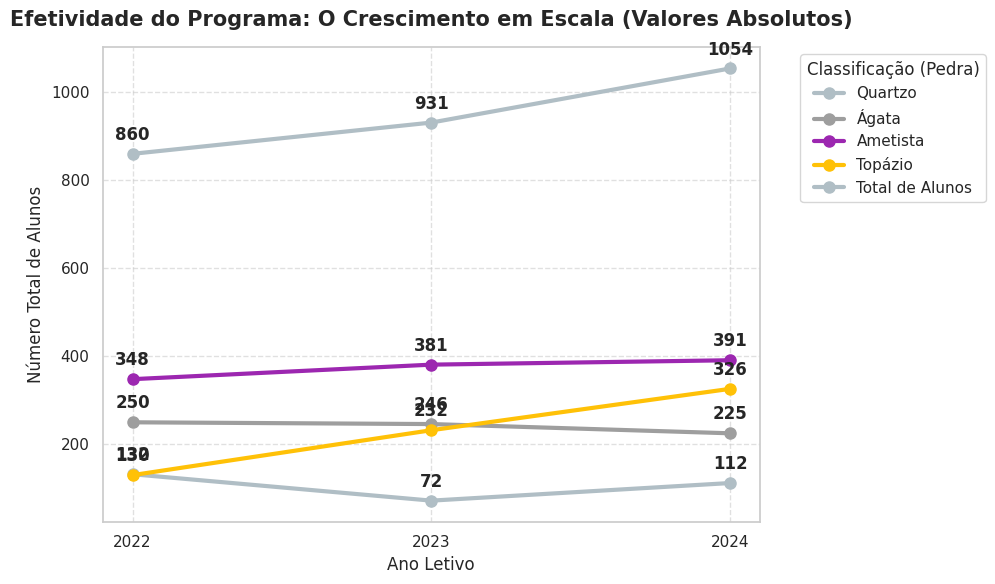

In [ ]:
# 3. Plotando o Gráfico de Linhas (Valores Absolutos)
fig, ax = plt.subplots(figsize=(10, 6))

cores = ['#B0BEC5', '#9E9E9E', '#9C27B0', '#FFC107'] # Cores das Pedras (Cinza, Prata, Roxo, Dourado)
evolucao_pedras.plot(kind='line', marker='o', linewidth=3, markersize=8, color=cores, ax=ax)

ax.set_title('Efetividade do Programa: O Crescimento em Escala (Valores Absolutos)', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Número Total de Alunos', fontsize=12)
ax.set_xlabel('Ano Letivo', fontsize=12)
ax.set_xticks(evolucao_pedras.index)

# Ajustando a legenda
ax.legend(title='Classificação (Pedra)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

# Adicionando os rótulos numéricos diretamente nas linhas para facilitar a leitura
for col in evolucao_pedras.columns:
    for ano, valor in zip(evolucao_pedras.index, evolucao_pedras[col]):
        if pd.notna(valor):
            ax.annotate(f'{int(valor)}', (ano, valor), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 📈 Resposta à Pergunta 10: Efetividade do Programa - Evolução ao longo do ciclo

A Descoberta Analítica: Para confirmar o impacto real do programa educacional, analisamos a evolução da distribuição dos alunos nas classificações evolutivas (Quartzo, Ágata, Ametista e Topázio) entre 2022 e 2024, observando tanto a proporção interna quanto o crescimento em escala (valores absolutos).

Os dados comprovam que o programa não apenas é efetivo, mas também altamente escalável.

Temos duas grandes comprovações de sucesso:

1. A Melhoria na Qualidade Proporcional (Gráfico 1 - Proporção): Se o programa é efetivo, a proporção de alunos nas pedras de excelência deve subir. E é exatamente isso que os dados mostram.

A proporção de alunos Topázio (nível máximo) dobrou, saltando de 15,1% em 2022 para impressionantes 30,9% em 2024.

Paralelamente, a soma da base de risco e nível básico (Quartzo + Ágata) encolheu substancialmente, caindo de 44,4% (2022) para apenas 31,9% (2024).

O programa ativamente "empurra" os alunos para cima.


2. A Prova da Escalabilidade (Gráfico 2 - Valores Absolutos): Muitos projetos sociais perdem a qualidade quando aumentam o número de assistidos. A Passos Mágicos provou o contrário.

O número absoluto de alunos Topázio explodiu, passando de 130 alunos (2022) para 326 alunos (2024).

O grupo Ametista também se manteve como a maior massa da ONG e continuou crescendo em volume absoluto (de 348 para 391 alunos).

Mesmo com a entrada de novos alunos, o número de estudantes no nível crítico (Quartzo) em 2024 (112 alunos) ainda é inferior ao volume que existia em 2022 (131 alunos).

💡 Conclusão Estratégica (O Insight para a Banca): Os indicadores confirmam o impacto real e transformador do programa. Em 2024, a Passos Mágicos possui 717 alunos concentrados apenas nos níveis de alta performance (Ametista e Topázio).

A Associação conseguiu o feito mais difícil na gestão de impacto social: expandiu rapidamente sua operação e o volume de alunos atendidos, e, ao mesmo tempo, elevou a qualidade e a taxa de sucesso acadêmico e emocional desses jovens.




---

